# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☐ Standard Analysis ☐ Research-Oriented  
**Group members:**  
- Mads Pagh
- Marcus Mofjeld

**Dataset:**  Spotify Playlists

**Initial task description (Module 1 perspective):**

We propose a project that critiques and expands upon the methodology presented in "Towards a Context-Aware Music
Recommendation Approach: What is Hidden in the Playlist Name?" [CITE]. The original authors demonstrated that
clustering playlist names to infer "listening contexts" can increase recommendation precision by 33% compared to
traditional collaborative filtering. However, their approach relied exclusively on k-means clustering. Our analysis goal
in this first part is Structure Discovery, specifically investigating the intrinsic geometry of these "listening contexts."
As noted in the course material, k-means is a Representative-based algorithm that assumes clusters are spherical,
compact, and distinct. We hypothesize that human-generated musical contexts are likely complex, arbitrary in shape,
and potentially nested, which makes the rigid partitioning of k-means a limitation. To test this, we will compare
the k-means baseline against alternative clustering paradigms: Subspace Clustering and Hierarchical Clustering. By
comparing these techniques, we aim to determine which structural definition best captures the semantic reality of user
playlists.

## 0. Reproducibility and Setup

In [3]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Source: https://www.kaggle.com/datasets/andrewmvd/spotify-playlists
- Number of instances: 12,902,045
- Number of features / entities: 4
- Missing values: 0
- Basic statistics:
Unique Users:            15,918
Unique Tracks:           2,036,899
Unique Raw Playlists:    157,530


In [8]:
from preprocessing.preprocessor import load_and_heal_data

# Load dataset (dataframe)
df = load_and_heal_data()

In [9]:
# View the first few rows of the dataframe
df.head()

,user_id,artistname,trackname,playlistname,homogenized_playlist
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010,hard rock 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010,hard rock 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010,hard rock 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010,hard rock 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010,hard rock 2010


### Preprocessing
Our preprocessing pipeline aims to match and improve upon that of [CITATION?]. The pipeline consists of the following main steps on the playlist names column:
#### Homogenization 
Homogenization is the process of extracting the base form (lemma) of a word. The process consists of two main steps. Firstly we use regular expressions to make all letters lowercase and strip out punctuation. Next we break all the words in the names into tokens and lemmatize them (e.g., converting "workouts" to "workout"). Practically this is done using the Natural Language Toolkit (NLTK) library. The aim with this process is to transform the messy inconsistent user-generated names into a standard format, which makes string matching more accurate in the clustering algorithms.

In [10]:
from preprocessing.preprocessor import homogenize_playlists
df = homogenize_playlists(df)

Column 'homogenized_playlist' already exists. Skipping homogenization.


#### Entity Filtering
The goal of entity filtering is to remove playlists that lack contextual information, or are strictly based on named entities (like specific artists, or bands). As we are trying to cluster based on the context described in the name, we filter out these non-contextual playlists to ensure our clustering models learn situational patterns rather than grouping artist discographies together.

To do this we run a strict filtering process, where we compare the playlist names against the artists present in the dataset, along with a set of predefined genres. To take it one step further, we use the spaCy NLP library to analyze the grammatical structure for further named entity recognition. The model looks for entities tagged as "person", "org" or "work of art", and removes playlists where this consists of 80% or more of the name. We also implement a "rescue mechanism", in which the script checks tokens for adjectives or verbs and ensures these playlists are kept, as the presence of an action or description implies context, regardless of the rest of the name.

In [11]:
from preprocessing.preprocessor import filter_entities
df = filter_entities(df)


[INFO] 'spotify_fully_processed.parquet' already exists. Loading it directly...


#### Stop-word Filtering
Stop-word filtering removes the words, which we do not want to expand and cluster on. Stop words define any words that are often used without providing semantic meaning. In our case we filter on both classic stop words such as "as" and "a" along with music specific stop words such as "track" and "playlist", which do not provide meaning to the playlist name. 

In [12]:
from preprocessing.preprocessor import remove_stop_words
df = remove_stop_words(df)


Stop words already filtered. Skipping.



#### Feature Expansion
The `expand_feature` function is responsible for the text preprocessing, which enriches the short strings, e.g. a playlist name, but appending related words to it. This technique provides more context for text-mining algorithms like TF-IDF. The flow of the function is the following:
1. First the input gets validated, an empty string is returned if not. 
2. A set is maintaned which stores the words, preventing duplicate entries. 
3. We then split the input strings into individual words and process them one by one. For each word, WordNet is used to find
    - Synonyms (Lemmas), which contain the exact same meaning. 
    - Hypernyms expanding general category words ('guitar' -> 'stringed instrument'). 
4. Lastly, the underscores from WordNet terms are replaced with spaces, and the final deduplicated set of original words, synonyms, and hypernyms is returned as a single, space-separated string. 

In [13]:
from preprocessing.preprocessor import expand_features
df = expand_features(df)


Expanded features already exist. Skipping expansion step.


### TF-IDF Creation and Analysis
We build and use a TF-IDF Matrix as a foundational data structure for our clustering algorithms. 

Term Frequency-Inverse Document Frequency (TF-IDF) is a statistical measure that evaluates how relevant a word is to a document within a larger collection by comparing local frequency to global rarity. Concretely, running the TfidfVectorizer transforms our preprocessed text data into a mathematical grid, where rows are the unique playlists, and our columns are the unique words present in all the names. The values in the matrix cells are scores representing the importance of a specific column's word to a specific row's playlist.

This representation allows for a mathematical translation of the strings in a format that supplies crucial context to the clustering models.
#### Building the TF-IDF
We will be using the TfidfVectorizer function from the sklearn library in tf-idf matrix creation.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

We care only for the entries that are flagged as being contextual from entity filtering, so we create a binary mask for further processing.

In [15]:
contextual_mask = df['is_contextual'] == True

Using the contextual mask we keep only the non-empty unique values from the expanded features column. 

In [16]:
unique_texts = df[contextual_mask]['expanded_features'].dropna().unique()

The imported function is called with parameters:
- min_df: This tells the vectorizer to completely ignore words that appear in fewer than 5 documents (playlists).
- max_df: Words appearing in more than 95% of the documents gets ignored too, this is because words that are extremely common across all playlists act as corpus-specific stop-words, i.e. if every playlist contained 'music' in their name, there would be no discriminative value to help seperate the playlists into distinct clusters. 
- max_features: We restrict the final vocabulary to contain only the top 5,678 most important features (words). The raw text data originally produced 24,712 unique features, following cumulative importance analysis we found that 80% of the information could be kept in the 5,678 top-most features, speeding up the clustering algorithms and dropping obscure words. 

Cumulative importance plot seen below, source-function (`plot_cumulative_importance`):
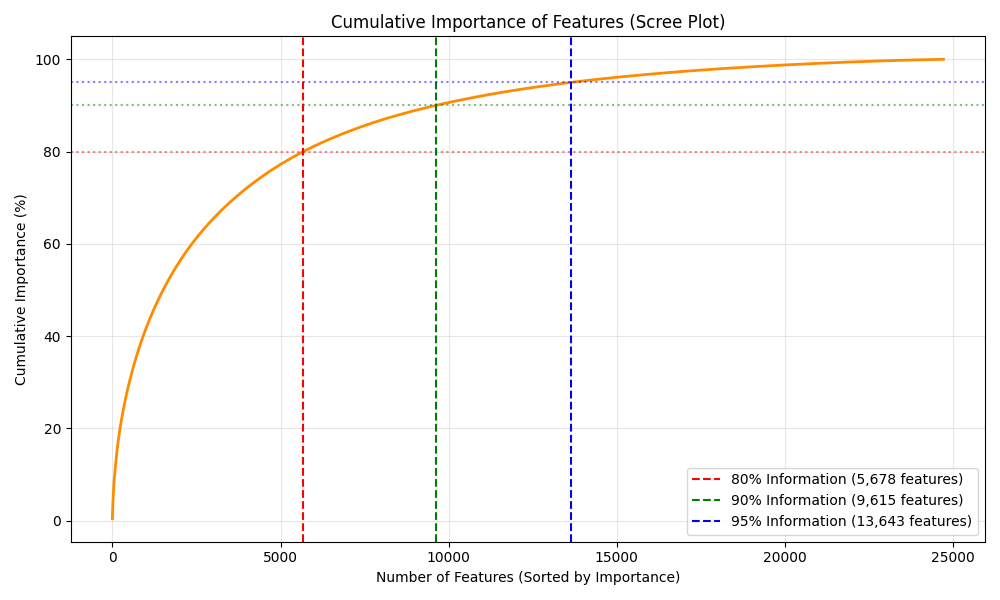

In [ ]:
# Notice 5678 features maintaining 80% of the information.
vectorizer = TfidfVectorizer(min_df=5, max_df=0.95, max_features=5678)
tfidf_matrix = vectorizer.fit_transform(unique_texts)

## 2. Module 1 — Vector-Space Analysis

### 2.1 Vector Representation

Explain your feature construction and distance measure here.

In [ ]:
# Construct vector representation
X = None  # Replace with actual feature matrix

### 2.2 Clustering Method

In [ ]:
# Implement clustering algorithm here
labels = None

## 3. Module 2 — Graph-Based Analysis

In [ ]:
import networkx as nx

# Build graph
G = nx.Graph()

## 4. Module 3 — Pattern / Text Mining

In [ ]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
